# Part 2.2: Weather TOBS Prediction

In [655]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

## Load Data & EDA

In [656]:
org_df = pd.read_csv('data/weather_handout.csv')
org_df['DATE'] = pd.to_datetime(org_df['DATE'])
org_df = org_df.sort_values('DATE').reset_index(drop=True)
org_df.set_index('DATE', inplace=True)

print(f'Shape: {org_df.shape}')
print(f'Date range: {org_df.index.min()} to {org_df.index.max()}')
print(f'\nMissing values:\n{org_df.isnull().sum()}')
print(f'\nDescribe:\n{org_df.describe()}')

Shape: (675, 6)
Date range: 2023-04-01 00:00:00 to 2025-03-31 00:00:00

Missing values:
PRCP      0
SNOW    128
SNWD    128
TMAX      0
TMIN      0
TOBS      0
dtype: int64

Describe:
             PRCP   SNOW   SNWD        TMAX        TMIN        TOBS
count  675.000000  547.0  547.0  675.000000  675.000000  675.000000
mean     0.136815    0.0    0.0   77.084444   54.311111   60.397037
std      0.395527    0.0    0.0   15.698390   16.068966   15.358215
min      0.000000    0.0    0.0   26.000000    7.000000   15.000000
25%      0.000000    0.0    0.0   66.500000   42.000000   49.000000
50%      0.000000    0.0    0.0   80.000000   58.000000   64.000000
75%      0.000000    0.0    0.0   90.000000   68.000000   73.000000
max      3.210000    0.0    0.0  106.000000   80.000000   88.000000


In [657]:
print(org_df.SNOW[org_df.SNOW == 0].count())
print(org_df.SNWD[org_df.SNWD == 0].count())

547
547


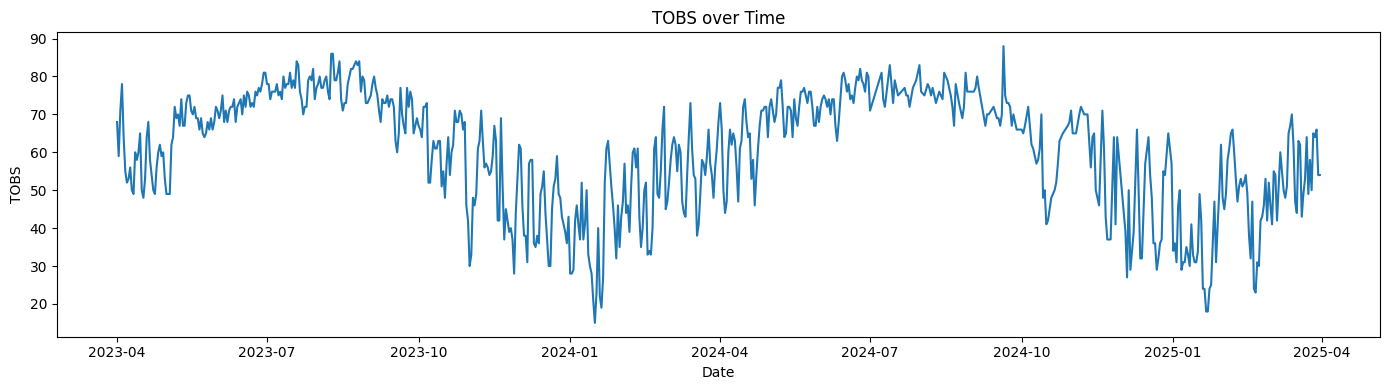

In [658]:
plt.figure(figsize=(14, 4))
plt.plot(org_df.index, org_df['TOBS'])
plt.title('TOBS over Time')
plt.xlabel('Date')
plt.ylabel('TOBS')
plt.tight_layout()
plt.show()

## Handle Missing Values

In [659]:
df = org_df.drop(['SNOW','SNWD'], axis=1)

# Interpolate missing dates — only for ARIMA/SARIMA (needs freq='D')
full_idx = pd.date_range(df.index.min(), df.index.max(), freq='D')
missing_dates = full_idx.difference(df.index)
print(f'Missing dates: {len(missing_dates)}')

df_daily = df.reindex(full_idx)
df_daily = df_daily.interpolate(method='linear')
df_daily.index.name = 'DATE'

print(f'\nOriginal shape (for RF models): {df.shape}')
print(f'Interpolated shape (for ARIMA/SARIMA): {df_daily.shape}')
print(f'Missing after interpolate:\n{df_daily.isnull().sum()}')

Missing dates: 56

Original shape (for RF models): (675, 4)
Interpolated shape (for ARIMA/SARIMA): (731, 4)
Missing after interpolate:
PRCP    0
TMAX    0
TMIN    0
TOBS    0
dtype: int64


## Train/Test Split (last 3 months = test)

In [660]:
split_date = '2025-01-01'
value_var = 'TOBS'

# For SARIMA — weekly resampled from interpolated daily
train_weekly = df_daily[df_daily.index < split_date][value_var].resample('W').mean()
test_weekly = df_daily[df_daily.index >= split_date][value_var].resample('W').mean()
train_weekly.index = pd.DatetimeIndex(train_weekly.index, freq='W')
test_weekly.index = pd.DatetimeIndex(test_weekly.index, freq='W')

# For RF models — original data (no interpolation)
train_df = df[df.index < split_date].copy()
test_df = df[df.index >= split_date].copy()

print(f'SARIMA (weekly):')
print(f'  Train: {len(train_weekly)} weeks ({train_weekly.index.min().date()} to {train_weekly.index.max().date()})')
print(f'  Test:  {len(test_weekly)} weeks ({test_weekly.index.min().date()} to {test_weekly.index.max().date()})')
print(f'\nRF models (original daily):')
print(f'  Train: {len(train_df)} ({train_df.index.min().date()} to {train_df.index.max().date()})')
print(f'  Test:  {len(test_df)} ({test_df.index.min().date()} to {test_df.index.max().date()})')

SARIMA (weekly):
  Train: 93 weeks (2023-04-02 to 2025-01-05)
  Test:  14 weeks (2025-01-05 to 2025-04-06)

RF models (original daily):
  Train: 585 (2023-04-01 to 2024-12-31)
  Test:  90 (2025-01-01 to 2025-03-31)


---

## SARIMA MODEL

### Stationarity Test

In [661]:
def test_adfuller(series, alpha=0.05):
    from statsmodels.tsa.stattools import adfuller
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    for key, value in result[4].items():
        print(f"Critical Value ({key}): {value}")
    if result[1] <= alpha:
        print("Reject the null hypothesis. Data is stationary")
    else:
        print("Do not reject the null hypothesis. Data is not stationary")

In [662]:
test_adfuller(train_weekly)

ADF Statistic: -3.7635901641953238
p-value: 0.0033025921342908025
Critical Value (1%): -3.5137900174243235
Critical Value (5%): -2.8979433868293945
Critical Value (10%): -2.5861907285474777
Reject the null hypothesis. Data is stationary


### Decomposition

<Figure size 2000x800 with 0 Axes>

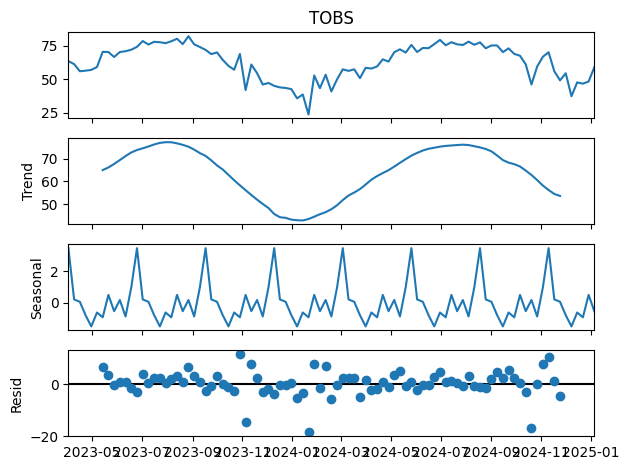

In [714]:
decomposition = seasonal_decompose(train_weekly, model='additive', period=12)
fig = plt.figure(figsize=(20, 8))
decomposition.plot()
plt.show()

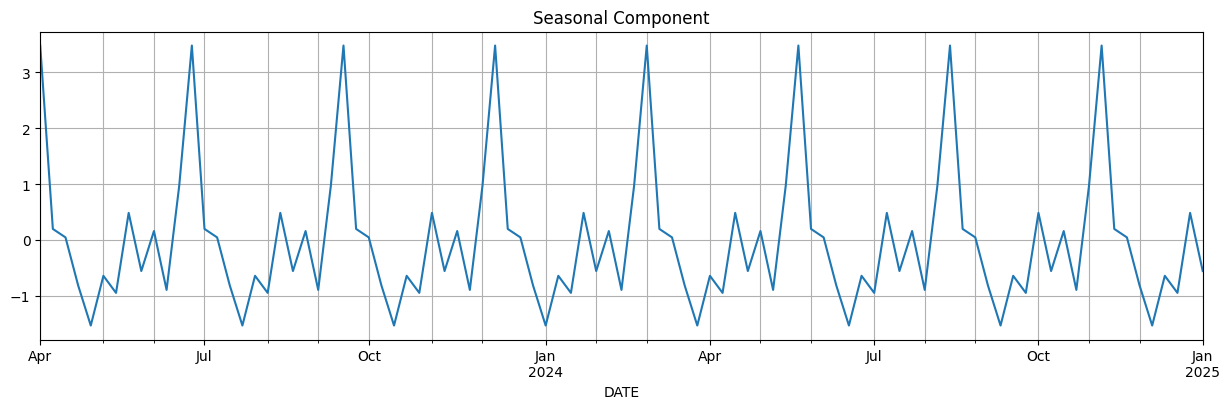

In [715]:
fig = plt.figure(figsize=(15, 4))
decomposition.seasonal.plot()
plt.grid(True, 'both')
plt.title('Seasonal Component')
plt.show()

selected_s = 12

### Find differencing d

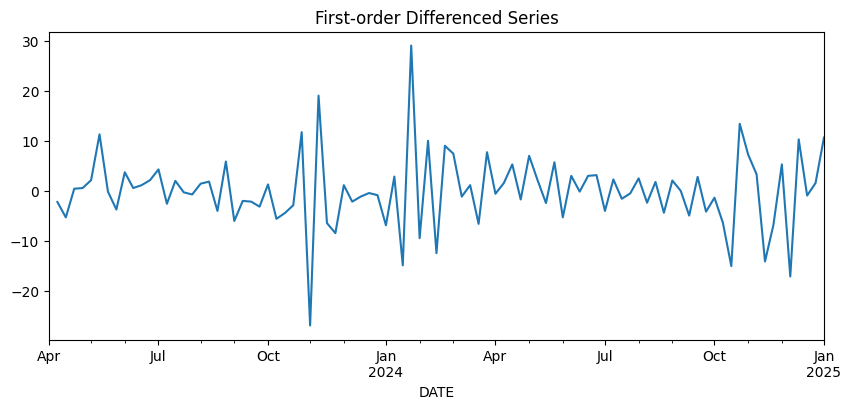

In [716]:
train_weekly_df = train_weekly.to_frame()
train_weekly_df['first_difference'] = (train_weekly - train_weekly.shift(1)).dropna()
train_weekly_df['first_difference'].plot(title="First-order Differenced Series", figsize=(10, 4))
plt.show()

In [717]:
test_adfuller(train_weekly_df['first_difference'].dropna())

ADF Statistic: -15.773220822625037
p-value: 1.1543398929454537e-28
Critical Value (1%): -3.50434289821397
Critical Value (5%): -2.8938659630479413
Critical Value (10%): -2.5840147047458037
Reject the null hypothesis. Data is stationary


In [718]:
# Set selected_d for ARIMA/SARIMA model
selected_d = 1

### Find differencing D for seasonal timeseries

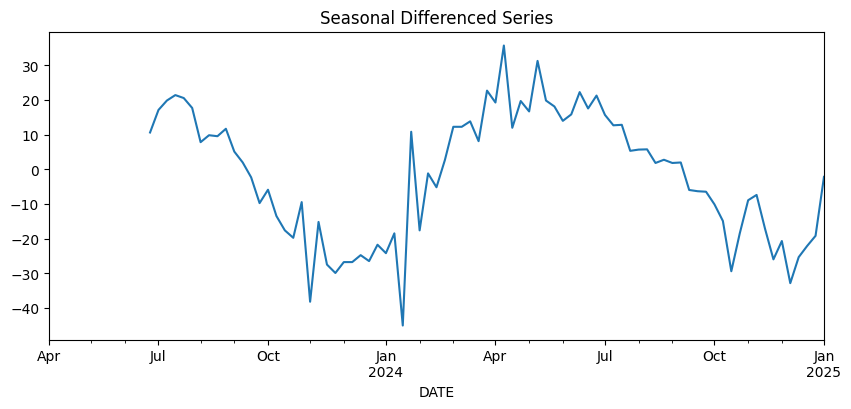

In [719]:
train_weekly_df['seasonal_difference'] = train_weekly - train_weekly.shift(selected_s)
train_weekly_df['seasonal_difference'].plot(title="Seasonal Differenced Series", figsize=(10, 4))
plt.show()

In [720]:
test_adfuller(train_weekly_df['seasonal_difference'].dropna())

ADF Statistic: -4.7125571751590245
p-value: 7.969884958323729e-05
Critical Value (1%): -3.528889992207215
Critical Value (5%): -2.9044395987933362
Critical Value (10%): -2.589655654274312
Reject the null hypothesis. Data is stationary


In [721]:
# Set selected_D for SARIMA model
selected_D = 1

### Identify p and q from PACF and ACF

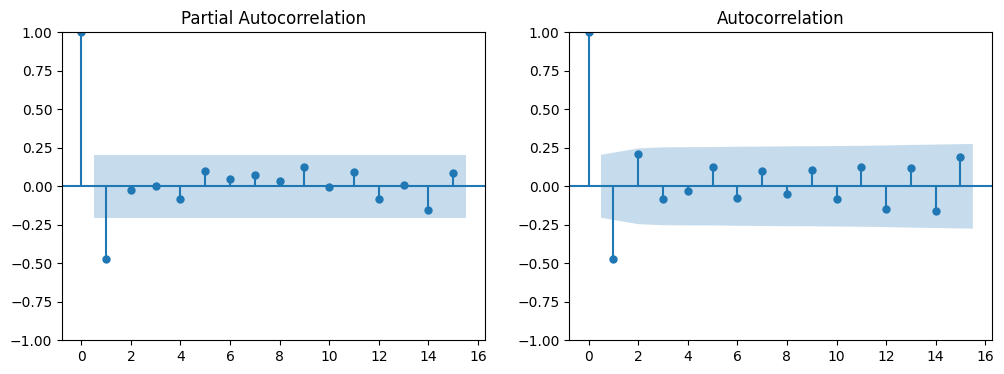

In [722]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_pacf(train_weekly_df['first_difference'].dropna(), lags=15, ax=ax[0])
plot_acf(train_weekly_df['first_difference'].dropna(), lags=15, ax=ax[1])
plt.show()

In [723]:
selected_p = 1
selected_q = 1

### Identify P and Q from PACF and ACF for seasonal timeseries

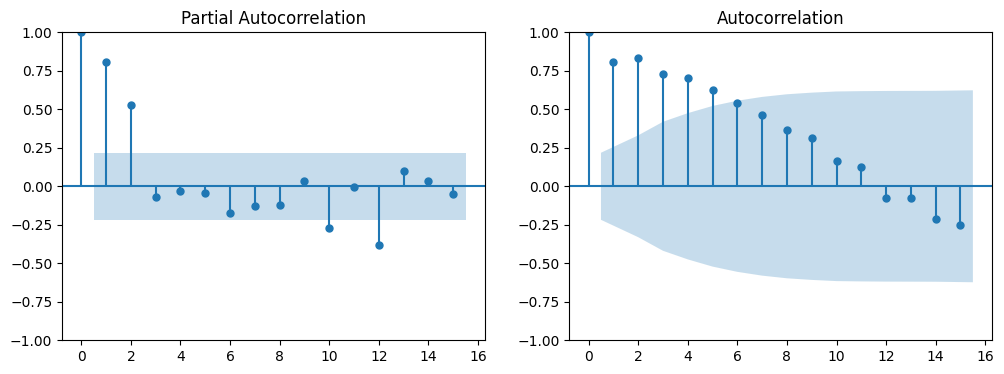

In [724]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_pacf(train_weekly_df['seasonal_difference'].dropna(), lags=15, ax=ax[0])
plot_acf(train_weekly_df['seasonal_difference'].dropna(), lags=15, ax=ax[1])
plt.show()

In [745]:
selected_P = 2
selected_Q = 0

### Select SARIMA model based on AIC and BIC

In [746]:
import statsmodels.api as sm

train_series = train_weekly.copy()

print(selected_s, selected_d, selected_D)
print(selected_p, selected_q)
print(selected_P, selected_Q)

12 1 1
1 1
2 0


In [737]:
# Grid search over p, q, P, Q
start_p = 0; end_p = 2
start_q = 0; end_q = 1
start_P = 0; end_P = 2
start_Q = 0; end_Q = 1

pdq_choices = []
for pi in range(start_p, end_p + 1):
    for qi in range(start_q, end_q + 1):
        for Pi in range(start_P, end_P + 1):
            for Qi in range(start_Q, end_Q + 1):
                pdq_choices.append(((pi, selected_d, qi), (Pi, selected_D, Qi, selected_s)))

results_list = []
for pdq_choice, PDQ_choice in pdq_choices:
    try:
        model = sm.tsa.statespace.SARIMAX(
            train_series,
            order=pdq_choice,
            seasonal_order=PDQ_choice,
        )
        result = model.fit(disp=False)
        results_list.append({
            'order': pdq_choice,
            'seasonal_order': PDQ_choice,
            'AIC': round(result.aic, 2),
            'BIC': round(result.bic, 2),
        })
    except Exception as e:
        pass

sarima_results_df = pd.DataFrame(results_list).sort_values('AIC')
print(sarima_results_df.to_string(index=False))

    order seasonal_order    AIC    BIC
(1, 1, 0)  (0, 1, 1, 12) 561.40 568.54
(1, 1, 1)  (0, 1, 1, 12) 563.26 572.79
(2, 1, 0)  (0, 1, 1, 12) 563.26 572.79
(1, 1, 0)  (1, 1, 1, 12) 563.30 572.83
(2, 1, 1)  (1, 1, 1, 12) 564.01 578.30
(0, 1, 1)  (0, 1, 1, 12) 564.91 572.05
(1, 1, 0)  (2, 1, 1, 12) 565.01 576.92
(1, 1, 1)  (1, 1, 1, 12) 565.18 577.09
(2, 1, 0)  (1, 1, 1, 12) 565.19 577.10
(2, 1, 1)  (0, 1, 1, 12) 565.26 577.17
(1, 1, 1)  (2, 1, 1, 12) 566.77 581.06
(2, 1, 0)  (2, 1, 1, 12) 566.79 581.09
(0, 1, 1)  (1, 1, 1, 12) 566.89 576.42
(0, 1, 1)  (2, 1, 1, 12) 568.36 580.27
(2, 1, 1)  (2, 1, 1, 12) 568.73 585.40
(1, 1, 0)  (2, 1, 0, 12) 569.64 579.16
(2, 1, 0)  (2, 1, 0, 12) 571.63 583.54
(1, 1, 1)  (2, 1, 0, 12) 571.63 583.54
(2, 1, 1)  (2, 1, 0, 12) 572.85 587.14
(1, 1, 0)  (1, 1, 0, 12) 573.42 580.56
(0, 1, 1)  (2, 1, 0, 12) 574.94 584.47
(2, 1, 0)  (1, 1, 0, 12) 575.37 584.90
(1, 1, 1)  (1, 1, 0, 12) 575.37 584.90
(2, 1, 1)  (1, 1, 0, 12) 576.00 587.91
(0, 1, 1)  (1, 1, 0, 12) 

### Fit SARIMA — compare manual vs grid search

In [738]:
# Manual selection from ACF/PACF analysis
manual_order = (selected_p, selected_d, selected_q)
manual_seasonal = (selected_P, selected_D, selected_Q, selected_s)

# Grid search best (by AIC)
grid_best = sarima_results_df.iloc[0]
grid_order = grid_best['order']
grid_seasonal = grid_best['seasonal_order']

print(f'Manual:      order={manual_order}, seasonal={manual_seasonal}')
print(f'Grid search: order={grid_order}, seasonal={grid_seasonal}')

# Fit both
model_manual = SARIMAX(train_series, order=manual_order, seasonal_order=manual_seasonal)
results_manual = model_manual.fit(disp=False)

model_grid = SARIMAX(train_series, order=grid_order, seasonal_order=grid_seasonal)
results_grid = model_grid.fit(disp=False)

print(f'\nManual      — AIC: {results_manual.aic:.2f}, BIC: {results_manual.bic:.2f}')
print(f'Grid search — AIC: {results_grid.aic:.2f}, BIC: {results_grid.bic:.2f}')

Manual:      order=(1, 1, 1), seasonal=(3, 1, 0, 12)
Grid search: order=(1, 1, 0), seasonal=(0, 1, 1, 12)

Manual      — AIC: 567.38, BIC: 581.67
Grid search — AIC: 561.40, BIC: 568.54


Manual      — RMSE: 15.00, MAE: 11.29
Grid search — RMSE: 13.73, MAE: 9.95

=> Grid search model is better (lower RMSE)


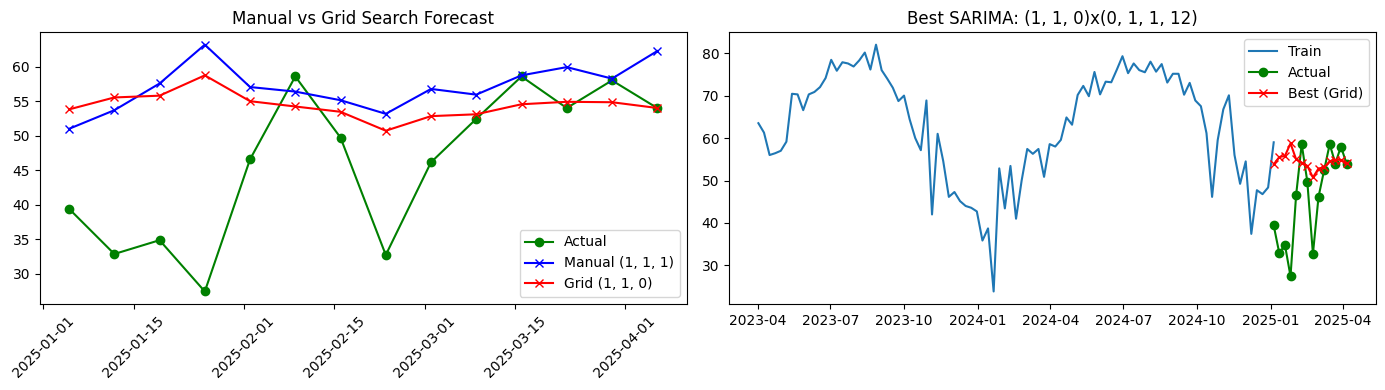


Selected: order=(1, 1, 0), seasonal=(0, 1, 1, 12)
RMSE: 13.73, MAE: 9.95


In [739]:
# Forecast both and compare
forecast_manual = results_manual.get_forecast(steps=len(test_weekly)).predicted_mean
forecast_grid = results_grid.get_forecast(steps=len(test_weekly)).predicted_mean
forecast_manual.index = test_weekly.index
forecast_grid.index = test_weekly.index

rmse_manual = root_mean_squared_error(test_weekly, forecast_manual)
mae_manual = mean_absolute_error(test_weekly, forecast_manual)
rmse_grid = root_mean_squared_error(test_weekly, forecast_grid)
mae_grid = mean_absolute_error(test_weekly, forecast_grid)

print(f'Manual      — RMSE: {rmse_manual:.2f}, MAE: {mae_manual:.2f}')
print(f'Grid search — RMSE: {rmse_grid:.2f}, MAE: {mae_grid:.2f}')

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].plot(test_weekly, label="Actual", marker="o", color='green')
ax[0].plot(forecast_manual, label=f"Manual {manual_order}", marker="x", color='blue')
ax[0].plot(forecast_grid, label=f"Grid {grid_order}", marker="x", color='red')
ax[0].legend()
ax[0].set_title("Manual vs Grid Search Forecast")
ax[0].tick_params(axis='x', labelrotation=45)

# Choose best
if rmse_grid <= rmse_manual:
    print(f'\n=> Grid search model is better (lower RMSE)')
    best_label = 'Grid'
    results_sarima = results_grid
    best_order = grid_order
    best_seasonal = grid_seasonal
    forecast_best = forecast_grid
    rmse_sarima = rmse_grid
    mae_sarima = mae_grid
else:
    print(f'\n=> Manual model is better (lower RMSE)')
    best_label = 'Manual'
    results_sarima = results_manual
    best_order = manual_order
    best_seasonal = manual_seasonal
    forecast_best = forecast_manual
    rmse_sarima = rmse_manual
    mae_sarima = mae_manual

# Plot best model
ax[1].plot(train_weekly, label="Train")
ax[1].plot(test_weekly, label="Actual", marker="o", color='green')
ax[1].plot(forecast_best, label=f"Best ({best_label})", marker="x", color='red')
ax[1].legend()
ax[1].set_title(f"Best SARIMA: {best_order}x{best_seasonal}")

plt.tight_layout()
plt.show()

print(f'\nSelected: order={best_order}, seasonal={best_seasonal}')
print(f'RMSE: {rmse_sarima:.2f}, MAE: {mae_sarima:.2f}')

---

In [747]:
print(results_sarima.summary())


                                      SARIMAX Results                                       
Dep. Variable:                                 TOBS   No. Observations:                   93
Model:             SARIMAX(1, 1, 0)x(0, 1, [1], 12)   Log Likelihood                -277.699
Date:                              Thu, 26 Mar 2026   AIC                            561.398
Time:                                      18:49:40   BIC                            568.544
Sample:                                  04-02-2023   HQIC                           564.263
                                       - 01-05-2025                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4990      0.087     -5.707      0.000      -0.670      -0.328
ma.S.L12      -0.99

---

## Model 2: Lagged TOBS + Random Forest

In [741]:
n_lags = 14

df_lag = df[['TOBS']].copy()
for i in range(1, n_lags + 1):
    df_lag[f'TOBS_lag{i}'] = df_lag['TOBS'].shift(i)
df_lag = df_lag.dropna()

train_lag = df_lag[df_lag.index < split_date]
test_lag = df_lag[df_lag.index >= split_date]

lag_features = [f'TOBS_lag{i}' for i in range(1, n_lags + 1)]
X_train_lag = train_lag[lag_features]
y_train_lag = train_lag['TOBS']
X_test_lag = test_lag[lag_features]
y_test_lag = test_lag['TOBS']

print(f'Train: {len(train_lag)}, Test: {len(test_lag)}')
print(f'Features: {lag_features}')

Train: 571, Test: 90
Features: ['TOBS_lag1', 'TOBS_lag2', 'TOBS_lag3', 'TOBS_lag4', 'TOBS_lag5', 'TOBS_lag6', 'TOBS_lag7', 'TOBS_lag8', 'TOBS_lag9', 'TOBS_lag10', 'TOBS_lag11', 'TOBS_lag12', 'TOBS_lag13', 'TOBS_lag14']


Lagged RF — RMSE: 9.76, MAE: 7.78


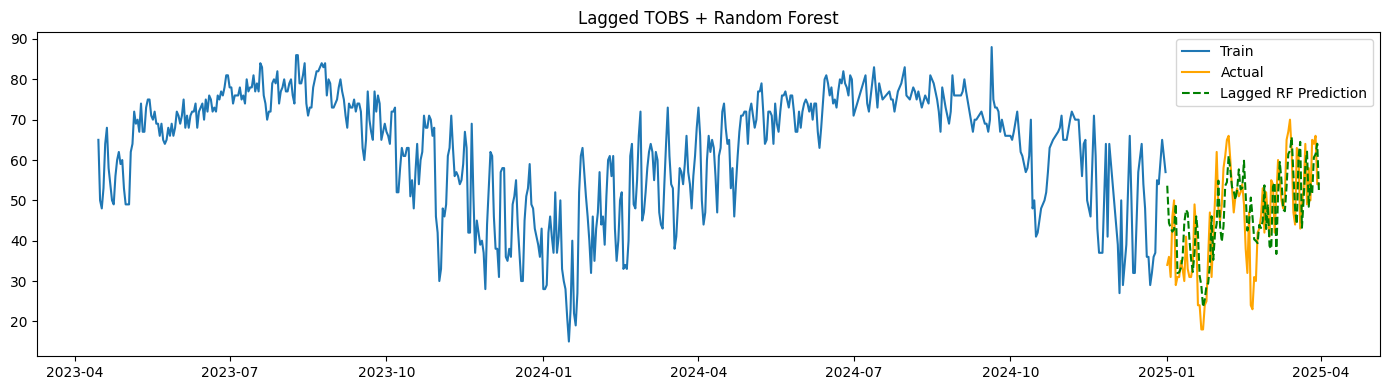

In [742]:
rf_lag = RandomForestRegressor(n_estimators=200, random_state=42)
rf_lag.fit(X_train_lag, y_train_lag)
y_pred_lag = rf_lag.predict(X_test_lag)

rmse_lag = root_mean_squared_error(y_test_lag, y_pred_lag)
mae_lag = mean_absolute_error(y_test_lag, y_pred_lag)
print(f'Lagged RF — RMSE: {rmse_lag:.2f}, MAE: {mae_lag:.2f}')

plt.figure(figsize=(14, 4))
plt.plot(train_lag.index, train_lag['TOBS'], label='Train')
plt.plot(test_lag.index, y_test_lag, label='Actual', color='orange')
plt.plot(test_lag.index, y_pred_lag, label='Lagged RF Prediction', color='green', linestyle='--')
plt.title('Lagged TOBS + Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

---

## Model 3: Other Features (no TOBS) + Random Forest

Other Features RF — RMSE: 5.78, MAE: 4.60


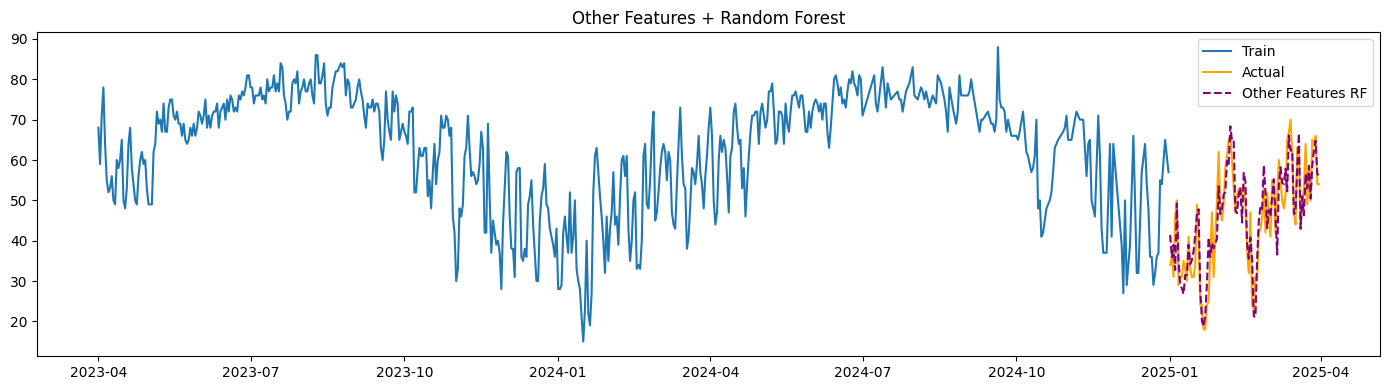

In [743]:
other_features = ['PRCP', 'TMAX', 'TMIN']

X_train_other = train_df[other_features]
y_train_other = train_df['TOBS']
X_test_other = test_df[other_features]
y_test_other = test_df['TOBS']

rf_other = RandomForestRegressor(n_estimators=200, random_state=42)
rf_other.fit(X_train_other, y_train_other)
y_pred_other = rf_other.predict(X_test_other)

rmse_other = root_mean_squared_error(y_test_other, y_pred_other)
mae_other = mean_absolute_error(y_test_other, y_pred_other)
print(f'Other Features RF — RMSE: {rmse_other:.2f}, MAE: {mae_other:.2f}')

plt.figure(figsize=(14, 4))
plt.plot(train_df.index, train_df['TOBS'], label='Train')
plt.plot(test_df.index, y_test_other, label='Actual', color='orange')
plt.plot(test_df.index, y_pred_other, label='Other Features RF', color='purple', linestyle='--')
plt.title('Other Features + Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

---

## Model Comparison

                      Model      RMSE      MAE
            SARIMA (weekly) 13.731379 9.947731
   Lagged TOBS + RF (daily)  9.759391 7.783944
Other Features + RF (daily)  5.777656 4.601204

Note: SARIMA evaluated on weekly averages, RF models on daily values


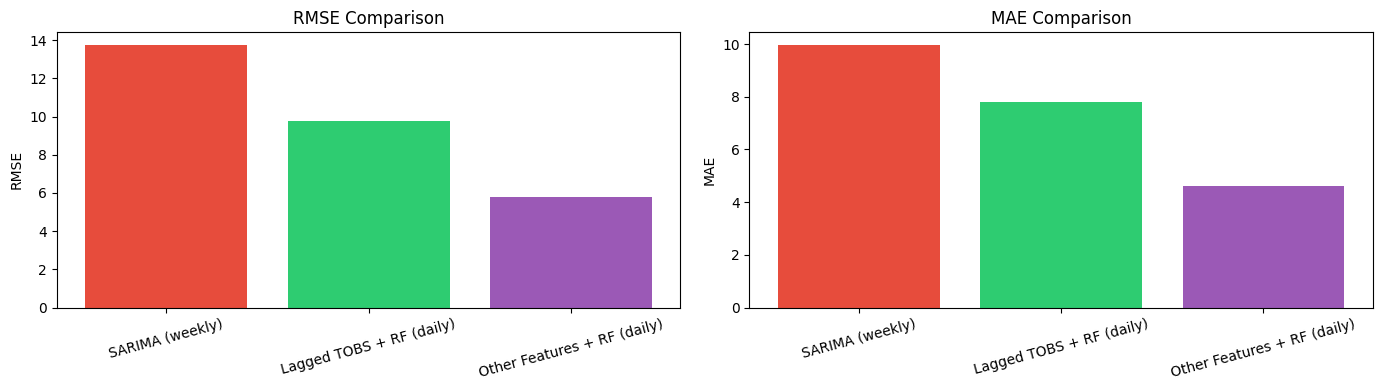

In [744]:
comparison = pd.DataFrame({
    'Model': ['SARIMA (weekly)', 'Lagged TOBS + RF (daily)', 'Other Features + RF (daily)'],
    'RMSE': [rmse_sarima, rmse_lag, rmse_other],
    'MAE': [mae_sarima, mae_lag, mae_other]
})
print(comparison.to_string(index=False))
print('\nNote: SARIMA evaluated on weekly averages, RF models on daily values')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ['#e74c3c', '#2ecc71', '#9b59b6']

axes[0].bar(comparison['Model'], comparison['RMSE'], color=colors)
axes[0].set_title('RMSE Comparison')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(comparison['Model'], comparison['MAE'], color=colors)
axes[1].set_title('MAE Comparison')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()